In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
system_id = 2107

In [3]:
my_path = Path('C:/Users/ch83b/Documents/DatSciStart/data_ds_project/systems/prize/2107/2107_electrical_data_v1.csv')

In [4]:
df_2107_elec = pd.read_csv(my_path)

In [22]:
df_2107_elec.head()

,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
0,2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2017-11-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2017-11-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
df_2107_elec['measured_on'] = pd.to_datetime(
        df_2107_elec['measured_on'], format='%Y-%m-%d %H:%M:%S'
    ).astype('datetime64[s]')

In [26]:
df_2107_elec[['measured_on']].describe()

,measured_on
count,632952
mean,2020-11-04 00:06:34
min,2017-11-01 00:00:00
25%,2019-05-04 12:28:45
50%,2020-11-03 23:57:30
75%,2022-05-07 12:26:15
max,2023-11-07 23:55:00


In [25]:
df_2107_elec[['measured_on']].dtypes

measured_on    datetime64[s]
dtype: object

In [5]:
df_2107_elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 632952 entries, 0 to 632951
Columns: 120 entries, measured_on to inv_24_ac_power_inv_149698
dtypes: float64(119), object(1)
memory usage: 579.5+ MB


In [8]:
df_2107_elec.columns.values[0:7]

array(['measured_on', 'inv_01_dc_current_inv_149579',
       'inv_01_dc_voltage_inv_149580', 'inv_01_ac_current_inv_149581',
       'inv_01_ac_voltage_inv_149582', 'inv_01_ac_power_inv_149583',
       'inv_02_dc_current_inv_149584'], dtype=object)

In [21]:
for j in df_2107_elec.columns:
    if 'cur' in j or 'volt' in j or 'pow' in j:
        print (j)

inv_01_dc_current_inv_149579
inv_01_dc_voltage_inv_149580
inv_01_ac_current_inv_149581
inv_01_ac_voltage_inv_149582
inv_01_ac_power_inv_149583
inv_02_dc_current_inv_149584
inv_02_dc_voltage_inv_149585
inv_02_ac_current_inv_149586
inv_02_ac_voltage_inv_149587
inv_02_ac_power_inv_149588
inv_03_dc_current_inv_149589
inv_03_dc_voltage_inv_149590
inv_03_ac_current_inv_149591
inv_03_ac_voltage_inv_149592
inv_03_ac_power_inv_149593
inv_04_dc_current_inv_149594
inv_04_dc_voltage_inv_149595
inv_04_ac_current_inv_149596
inv_04_ac_voltage_inv_149597
inv_04_ac_power_inv_149598
inv_05_dc_current_inv_149599
inv_05_ac_current_inv_149601
inv_05_ac_voltage_inv_149602
inv_05_ac_power_inv_149603
inv_06_dc_current_inv_149604
inv_06_dc_voltage_inv_149605
inv_06_ac_current_inv_149606
inv_06_ac_voltage_inv_149607
inv_06_ac_power_inv_149608
inv_07_dc_current_inv_149609
inv_07_dc_voltage_inv_149610
inv_07_ac_current_inv_149611
inv_07_ac_voltage_inv_149612
inv_07_ac_power_inv_149613
inv_08_dc_current_inv_149614

In [9]:
inv_01_cols = ['measured_on',
               'inv_01_dc_current_inv_149579', 'inv_01_dc_voltage_inv_149580',
               'inv_01_ac_current_inv_149581', 'inv_01_ac_voltage_inv_149582',
               'inv_01_ac_power_inv_149583']

In [10]:
df_2107_inv_1 = df_2107_elec.loc[:, inv_01_cols]

Note: Current is in amperes, Voltage is in Volts, so current * voltage is in W.  But power is measured in KW.

In [73]:
df_2107_inv_1['inv_01_ac_power_manual'] = df_2107_inv_1['inv_01_ac_current_inv_149581'] * df_2107_inv_1['inv_01_ac_voltage_inv_149582'] /1000

In [74]:
df_2107_inv_1['ac_power_difference'] = df_2107_inv_1['inv_01_ac_power_inv_149583'] - df_2107_inv_1['inv_01_ac_power_manual']

In [75]:
df_2107_inv_1['abs_ac_power_difference'] = df_2107_inv_1['ac_power_difference'].apply(lambda x: np.abs(x))

In [81]:
df_2107_inv_1['ac_power_difference'].describe()

count    632586.000000
mean          4.204209
std           6.626828
min          -6.449867
25%           0.000000
50%           0.000000
75%           7.137922
max          29.099844
Name: ac_power_difference, dtype: float64

In [111]:
df_2107_inv_1['inv_01_ac_power_inv_149583'].describe()

count    632586.000000
mean          6.363338
std           9.933949
min           0.000000
25%           0.000000
50%           0.000000
75%          10.763000
max          30.096000
Name: inv_01_ac_power_inv_149583, dtype: float64

In [110]:
df_2107_inv_1['abs_ac_power_difference'].describe()

count    632586.000000
mean          4.234127
std           6.607753
min           0.000000
25%           0.000000
50%           0.000000
75%           7.137922
max          29.099844
Name: abs_ac_power_difference, dtype: float64

In [84]:
df_2107_inv_1['abs_ac_power_difference'].value_counts(dropna=False)

abs_ac_power_difference
0.000000    333860
NaN            366
0.012000        19
0.189775        19
0.189988        18
             ...  
0.045195         1
0.013040         1
0.099696         1
0.164384         1
7.076381         1
Name: count, Length: 292303, dtype: int64

In [78]:
df_2107_inv_1['ac_power_difference'].value_counts(dropna=False)

ac_power_difference
 0.000000    333860
 NaN            366
 0.012000        19
-0.189775        19
-0.189988        18
              ...  
 0.045195         1
-0.013040         1
-0.099696         1
-0.164384         1
 7.076381         1
Name: count, Length: 292303, dtype: int64

In [86]:
df_2107_inv_1['ac_power_law_holds'] = df_2107_inv_1['ac_power_difference'].apply(lambda x: np.isclose(x, 0))
df_2107_inv_1['ac_power_law_holds'].value_counts(dropna=False)

ac_power_law_holds
True     333860
False    299092
Name: count, dtype: int64

In [87]:
def close_enough(row):
    if row.abs_ac_power_difference <= 5:
        return True
    elif row.abs_ac_power_difference > 5:
        return False
    else:
        return pd.NA

In [88]:
df_2107_inv_1['close_enough'] = df_2107_inv_1.apply(close_enough, axis=1)

In [89]:
df_2107_inv_1['close_enough'].value_counts(dropna=False)

close_enough
True     452536
False    180050
<NA>        366
Name: count, dtype: int64

In [135]:
def weakly_close_enough(row):
    if row.abs_ac_power_difference <= 10:
        return True
    elif row.abs_ac_power_difference > 10:
        return False
    else:
        return pd.NA

In [136]:
df_2107_inv_1['weakly_close_enough'] = df_2107_inv_1.apply(weakly_close_enough, axis=1)

In [137]:
df_2107_inv_1['weakly_close_enough'].value_counts(dropna=False)

weakly_close_enough
True     498760
False    133826
<NA>        366
Name: count, dtype: int64

In [96]:
def one_percent_off(row):
    if row.abs_ac_power_difference <= 0.01*row.inv_01_ac_power_inv_149583:
        return True
    elif row.abs_ac_power_difference > 0.01*row.inv_01_ac_power_inv_149583:
        return False
    else:
        return pd.NA

In [97]:
df_2107_inv_1['within_one_percent'] = df_2107_inv_1.apply(one_percent_off, axis=1)

In [98]:
df_2107_inv_1['within_one_percent'].value_counts(dropna=False)

within_one_percent
True     334134
False    298452
<NA>        366
Name: count, dtype: int64

In [99]:
df_2107_inv_1.groupby('within_one_percent').mean(numeric_only=True)

,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_01_ac_power_manual,power_difference,power_law_holds,ac_power_difference,ac_power_law_holds,abs_ac_power_difference
within_one_percent,,,,,,,,,,,
False,20.885003,669.00407,15.798983,286.611932,13.487099,4.576038,-4562.550462,0.00000,8.911061e+00,0.00000,8.974470
True,0.005721,6.76119,0.001146,2.157390,0.000320,0.000320,-0.320120,0.99918,1.153264e-08,0.99918,0.000002


In [ ]:
df_2107_inv_1_small = df_2107_inv_1[
    (df_2107_inv_1['close_enough'] == True)
]

In [105]:
df_2107_inv_1_small['inv_01_ac_current_inv_149581'].describe()

count    452536.000000
mean          0.864665
std           1.903586
min           0.000000
25%           0.000000
50%           0.000000
75%           0.670000
max          29.792000
Name: inv_01_ac_current_inv_149581, dtype: float64

In [108]:
df_2107_inv_1_small_nonzero = df_2107_inv_1_small[
    df_2107_inv_1_small['inv_01_ac_current_inv_149581'] > 0
]

In [109]:
df_2107_inv_1_small_nonzero['inv_01_ac_current_inv_149581'].describe()

count    117257.000000
mean          3.337044
std           2.394678
min           0.473000
25%           1.339000
50%           2.505000
75%           5.055000
max          29.792000
Name: inv_01_ac_current_inv_149581, dtype: float64

In [ ]:
df_2107_inv_1_big = df_2107_inv_1[df_2107_inv_1['close_enough'] == False]

In [107]:
df_2107_inv_1_big['inv_01_ac_current_inv_149581'].describe()

count    180050.000000
mean         24.017379
std           7.836199
min           2.919000
25%          17.352000
50%          25.436000
75%          31.056000
max          36.363000
Name: inv_01_ac_current_inv_149581, dtype: float64

In [67]:
df_2107_inv_1.groupby('within_one_percent').median(numeric_only=True)

,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_01_ac_power_manual,power_difference,power_law_holds,ac_power_difference,ac_power_law_holds,abs_ac_power_difference
within_one_percent,,,,,,,,,,,
False,18.302,678.434,14.408,286.619,12.261,4123.091005,-4110.894753,0.0,-4110.894753,0.0,4110.894753
True,0.000,0.000,0.000,0.000,0.000,0.000000,0.000000,1.0,0.000000,1.0,0.000000


In [124]:
df_2107_inv_1_small_nonzero_pow = df_2107_inv_1[
    (df_2107_inv_1['close_enough'] == True)
    & (df_2107_inv_1['inv_01_ac_power_inv_149583'] >= 0.5)
]

In [125]:
df_2107_inv_1_small_nonzero_pow['inv_01_ac_power_inv_149583'].describe()

count    81929.000000
mean         3.334919
std          2.099436
min          0.500000
25%          1.412000
50%          3.005000
75%          5.073000
max         11.733000
Name: inv_01_ac_power_inv_149583, dtype: float64

In [126]:
df_2107_inv_1_large_pow = df_2107_inv_1[
    (df_2107_inv_1['close_enough'] == False)
    & (df_2107_inv_1['inv_01_ac_power_inv_149583'] >= 0.5)
]

In [127]:
df_2107_inv_1_large_pow['inv_01_ac_power_inv_149583'].describe()

count    180049.000000
mean         20.813254
std           6.979528
min           7.360000
25%          14.835000
50%          22.005000
75%          27.099000
max          30.096000
Name: inv_01_ac_power_inv_149583, dtype: float64

In [122]:
df_2107_nonzero_pow = df_2107_inv_1[
    (df_2107_inv_1['inv_01_ac_power_inv_149583'] >= 0.5)
]

In [123]:
df_2107_nonzero_pow['inv_01_ac_power_inv_149583'].describe()

count    261978.000000
mean         15.347213
std          10.025852
min           0.500000
25%           5.529000
50%          15.567000
75%          24.920000
max          30.096000
Name: inv_01_ac_power_inv_149583, dtype: float64

In [128]:
import seaborn as sns

<Axes: xlabel='inv_01_ac_power_inv_149583', ylabel='Count'>

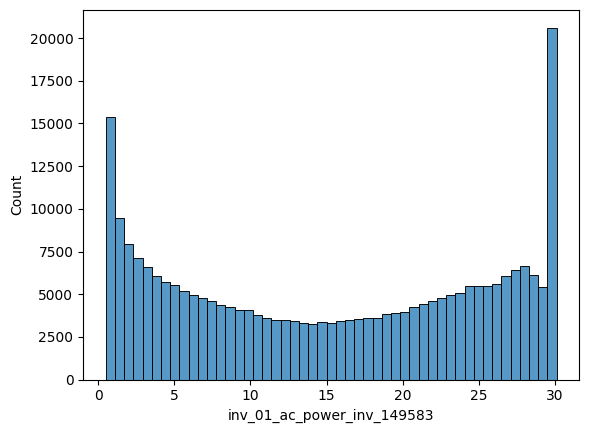

In [129]:
sns.histplot(
    data = df_2107_nonzero_pow,
    x = 'inv_01_ac_power_inv_149583'
)

In [131]:
df_2107_non_extreme_pow = df_2107_nonzero_pow = df_2107_inv_1[
    (df_2107_inv_1['inv_01_ac_power_inv_149583'] >= 0.5)
    & (df_2107_inv_1['inv_01_ac_power_inv_149583'] <= 29.5)
]

In [132]:
df_2107_non_extreme_pow['inv_01_ac_power_inv_149583'].describe()

count    241430.000000
mean         14.111631
std           9.466108
min           0.500000
25%           4.952000
50%          13.704000
75%          23.159000
max          29.500000
Name: inv_01_ac_power_inv_149583, dtype: float64

In [134]:
df_2107_non_extreme_pow['abs_ac_power_difference'].describe()

count    241430.000000
mean          9.358053
std           6.331901
min           0.000034
25%           3.257447
50%           9.094977
75%          15.396673
max          20.449802
Name: abs_ac_power_difference, dtype: float64

In [138]:
df_2107_non_extreme_pow['close_enough'].value_counts(dropna=False)

close_enough
False    159501
True      81929
Name: count, dtype: int64

<Axes: xlabel='inv_01_ac_power_inv_149583', ylabel='Count'>

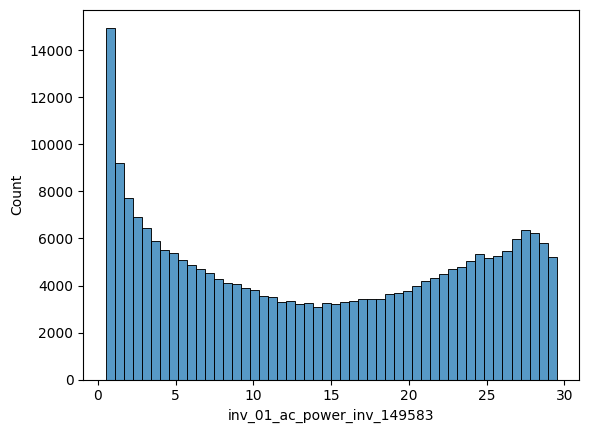

In [133]:
sns.histplot(
    data = df_2107_non_extreme_pow,
    x = 'inv_01_ac_power_inv_149583'
)